In [ ]:
if "BrentScheme" not in locals():
  !pip install "git+https://github.com/perryGabriel/brent-scheme.git"
  from brentscheme import *
import numpy as np
import torch
from tqdm import trange
import pandas as pd
import time
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
scheme = BrentScheme(n=3, d=2, m=4, p=8, verbose=1)
factory = SchemaFactory()
printer = SchemeDisplay()
manipulator = SchemeManipulator()
stepper = Stepper()
trainer = Trainer()

A scheme for (3 x 2) @ (2 x 4) using 8 products: complexity is n^1.963


In [ ]:
# @title File Save/Read Functions

# printer.test(scheme, verbose=0)
# round = lambda x,y:x # needed if dump_to_file throws an error - remember to use number= to avoid a long file name

# Save the scheme to Colab
# manipulator.set_norm(scheme, 2)
# score = printer.dump_to_file(scheme, number = -3.145)
# print(f"Score: {score}")

# Download the file from Colab to your computer. Remember to specify which scheme you want!
# download_file(n=scheme.n, d=scheme.d, m=scheme.m, p=scheme.p, number=score, scheme_or_diagram='scheme')

# Read into locals() a scheme from Colab's files. Remember to specify which scheme you want!
# factory.set_scheme(scheme, 'random', n=3, d=3, m=3, p=22)
# factory.read_from_files(scheme, n=scheme.n, d=scheme.d, m=scheme.m, p=scheme.p, number=-3.130, verbose=2)

# Delete a scheme from Colab. Remember to specify which scheme you want!
# delete_file(n=scheme.n, d=scheme.d, m=scheme.m, p=scheme.p, number=score, scheme_or_diagram='scheme')

In [ ]:
#@title Plot data
def plot_one(df, title, xlabel, ylabel, xvar, yvar, color='blue', label=None, alpha=0.2, **kwargs):
  _df = df.copy()

  # Filter the DataFrame based on the provided keyword arguments
  for key, value in kwargs.items():
    _df = _df[_df[key] == value]

  # Plot the filtered data
  # plt.figure(figsize=(10, 6))
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  if label is None:
    plt.scatter(_df[xvar], _df[yvar], color=color, alpha=alpha)
  else:
    plt.scatter(_df[xvar], _df[yvar], color=color, alpha=alpha, label=label)

In [ ]:
#@title Test Schemes of a given Size n,p for some iterable of seeds
# add default seed selector None that just finds a new seed from the data for that n
def test_schemes(n, p, seeds, epochs, filename, num_rotations=0, step_size=0):
  try:
    # Try to load existing data
    df = pd.read_csv(filename)
  except FileNotFoundError:
    # Create a new DataFrame if file doesn't exist
    df = pd.DataFrame()

  for seed in seeds:
    torch.random.manual_seed(seed)
    np.random.seed(seed)

    new_sample = pd.DataFrame(columns = ['seed', 'n', 'p', 'epochs', 'L1 err', 'L2 err', 'Linf err', 'time'])

    start_time = time.time()
    scheme = BrentScheme()
    factory.set_scheme(scheme, 'random', n=n, d=n, m=n, p=p)
    if step_size > 0:
      for i in range(epochs//step_size):
        stepper.epoch_pseudoinverse(scheme, batch_size=step_size)
        data = printer.test(scheme, verbose=1)
        end_time = time.time()
        new_sample.loc[len(new_sample.index)] = [seed, n, p, (i+1)*step_size, data[0], data[1], data[2], end_time - start_time]
    else:
      stepper.epoch_pseudoinverse(scheme, batch_size=epochs)
      data = printer.test(scheme, verbose=1)
      end_time = time.time()
      new_sample.loc[len(new_sample.index)] = [seed, n, p, epochs, data[0], data[1], data[2], end_time - start_time]

    for i in range(num_rotations):
      manipulator.change_basis(scheme, L=random_unitary(n), M=random_unitary(n), R=random_unitary(n))
      data = printer.test(scheme, verbose=1)
      new_sample.loc[len(new_sample.index)] = [seed, n, p, epochs, data[0], data[1], data[2], end_time - start_time]

    # Append sample to DataFrame
    df = pd.concat((df, new_sample), ignore_index=True)

    # Save updated DataFrame to Google Drive
    df.to_csv(filename, index=False)

In [ ]:
#@title Test Composite Schemes
def test_composed_schemes(n1, n2, p1, p2, epochs, filename, seeds1=None, seeds2=None, num_rotations=0, step_size=0):
  try:
    # Try to load existing data
    df = pd.read_csv(filename)
  except FileNotFoundError:
    # Create a new DataFrame if file doesn't exist
    df = pd.DataFrame(columns = ['seed1', 'seed2', 'L1 err', 'L2 err', 'Linf err',
                                 'n1', 'p1', 'L1 err1', 'L2 err1', 'Linf err1',
                                 'n2', 'p2', 'L1 err2', 'L2 err2', 'Linf err2',
                                 'epochs', 'time'])

  if seeds1 is None:
    # find a seed not in df
    df1 = df[(df['n1'] == n1) & (df['p1'] == p1)]
    seeds1 = [0 if df1['seed1'].empty else df1['seed1'].max() + 1]
  if seeds2 is None:
    # find a seed not in df
    df2 = df[(df['n2'] == n2) & (df['p2'] == p2)]
    seeds2 = [0 if df2['seed2'].empty else df2['seed2'].max() + 1]

  for seed1 in seeds1:
    for seed2 in seeds2:
      new_sample = pd.DataFrame(columns = ['seed1', 'seed2', 'L1 err', 'L2 err', 'Linf err',
                                           'n1', 'p1', 'L1 err1', 'L2 err1', 'Linf err1',
                                           'n2', 'p2', 'L1 err2', 'L2 err2', 'Linf err2',
                                           'epochs', 'time'])

      start_time = time.time()

      torch.random.manual_seed(seed1)
      np.random.seed(seed1)
      inner = BrentScheme()
      factory.set_scheme(inner, 'random', n=n1, d=n1, m=n1, p=p1)
      stepper.epoch_pseudoinverse(inner, batch_size=epochs)
      data1 = printer.test(inner, verbose=1)

      torch.random.manual_seed(seed2)
      np.random.seed(seed2)
      outer = BrentScheme()
      factory.set_scheme(outer, 'random', n=n2, d=n2, m=n2, p=p2)
      stepper.epoch_pseudoinverse(outer, batch_size=epochs)
      data2 = printer.test(outer, verbose=1)

      scheme = factory.compose_schemes(outer, inner)
      data3 = printer.test(scheme, verbose=1)
      end_time = time.time()
      new_sample.loc[len(new_sample.index)] = [seed1, seed2, data3[0], data3[1], data3[2],
                                               n1, p1, data1[0], data1[1], data1[2],
                                               n2, p2, data2[0], data2[1], data2[2],
                                               epochs, end_time - start_time]

      for i in range(num_rotations):
        manipulator.change_basis(scheme, L=random_unitary(n1*n2), M=random_unitary(n1*n2), R=random_unitary(n1*n2))
        data3 = printer.test(scheme, verbose=1)
        end_time_full = time.time()
        new_sample.loc[len(new_sample.index)] = [seed1, seed2, data3[0], data3[1], data3[2],
                                               n1, p1, data1[0], data1[1], data1[2],
                                               n2, p2, data2[0], data2[1], data2[2],
                                               epochs, end_time - start_time]
      # Append sample to DataFrame
      df = pd.concat((df, new_sample), ignore_index=True)

      # Save updated DataFrame to Google Drive
      df.to_csv(filename, index=False)

In [ ]:
#@title Set Up File Location
if False:
  from google.colab import drive
  drive.mount('/content/drive')
  data_location = '/content/drive/MyDrive'
else:
  data_location = '/content'

# filename = data_location + '/matmul_schemes.csv'
filename = data_location + '/matmul_schemes_prods2.csv'
# filename = data_location + '/matmul_schemes_log.csv'

In [ ]:

for n1 in range(2,4):
  for n2 in range(n1,5):
    p1 = n1**2
    p2 = n2**2
    print(f'testing n1={n1}, p1={p1}; n2={n2}, p2={p2}')
    test_composed_schemes(n1, n2, p1, p2, epochs=0, filename=filename, seeds1=trange(20), seeds2=range(20))

testing n1=2, p1=4; n2=2, p2=4


  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipython-input-888793472.py:62: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat((df, new_sample), ignore_index=True)
100%|██████████| 20/20 [00:07<00:00,  2.63it/s]


testing n1=2, p1=4; n2=3, p2=9


100%|██████████| 20/20 [00:10<00:00,  1.84it/s]


testing n1=2, p1=4; n2=4, p2=16


100%|██████████| 20/20 [00:16<00:00,  1.19it/s]


testing n1=3, p1=9; n2=3, p2=9


100%|██████████| 20/20 [00:25<00:00,  1.26s/it]


testing n1=3, p1=9; n2=4, p2=16


100%|██████████| 20/20 [01:13<00:00,  3.67s/it]


In [ ]:
def num_epochs(n):
  # sometimes the catchments leak into eachother after many epochs.
  # Example: for the first 100 seeds, n=5 has only one catchement until 120 epochs, where seed=0 drops a catchement
  # For n=2 and 3, 250 epochs gets many lines stable (for now)
  # it seems that for larger n, it takes longer for other catchments to appear. The curse of dimentionality. Momentum?
  return [-1,-1,150,150,100,10,5,4,4,3,3,3,3,3,3][n] if n < 14 else 0

# n=2
# for p in trange(n**2,n**2+n): # test p's

for n in range(5,5): # test n's : 9 mins to do 40 seeds
  p = int(n**2 * np.log2(n))
  print(f'testing n={n}, p={p}')
# TRY n=6 UNTIL A NEW CATCHMENT APPEARS
# also try composing schemes of various accuracies and see where they land in the product scheme (multiple product catchements?)
  test_schemes(n=n, p=p, seeds=trange(100), epochs=200, filename=filename, num_rotations=0, step_size=0)

Number of rows: 2000


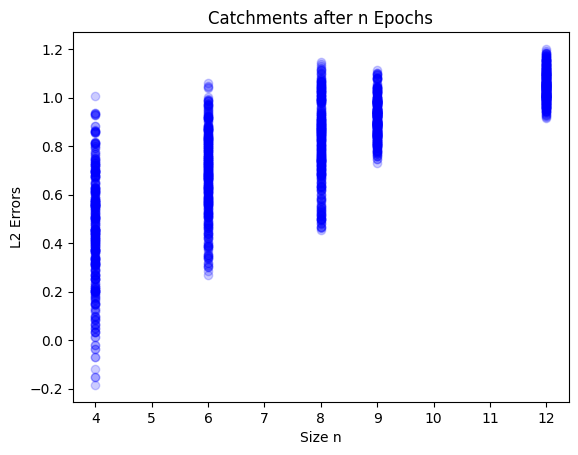

In [ ]:
#@title Read data from file
df = pd.read_csv(filename)
df['n'] = df.n1 * df.n2
df['p'] = df.p1 * df.p2
alpha = 0.2
print(f"Number of rows: {len(df)}")

# Save updated DataFrame to Google Drive
# df.to_csv(filename, index=False)

# n=6
# for p in range(n**2,n**2+n):
for n in df.n.unique(): # test n's
  plot_one(df, f"Catchments after n Epochs", "Size n", "L2 Errors", 'n', 'L2 err', alpha=alpha, n=n)
plt.show()

# plot_one(df, "Catchments after Epochs", "Epochs", "L1 Errors", 'epochs', 'L1 err', alpha=alpha, n=2, p=4)
# plot_one(df, "Catchments after Epochs", "Epochs", "Linf Errors", 'epochs', 'Linf err', alpha=alpha, n=2, p=4)

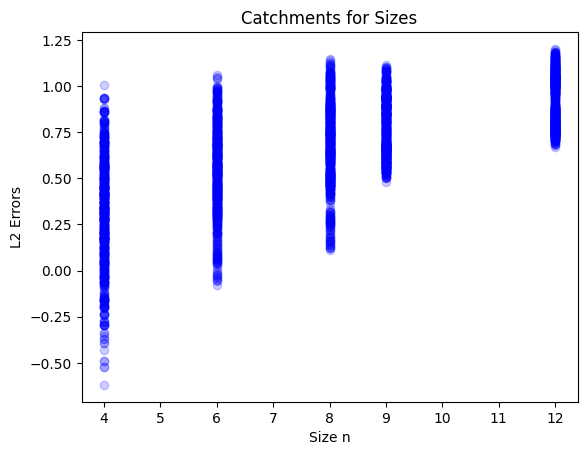

In [ ]:
#@title Display Errors By Size
plot_one(df, "Catchments for Sizes", "Size n", "L1 Errors", 'n', 'L1 err', alpha=alpha)
plot_one(df, "Catchments for Sizes", "Size n", "L2 Errors", 'n', 'L2 err', alpha=alpha)
plt.show()

In [ ]:
#@title prompt: in a dataframe df, for each unique value in column p, find the entry with minimum value in the column L2 err and display the results

# Group the DataFrame by 'p' and find the index of the minimum 'L2 err' for each group
min_indices = df.groupby('p')['L2 err'].idxmin()

# Display the rows with the minimum 'L2 err' for each unique 'p'
df_best = df.loc[min_indices].sort_values(by='L2 err')
df_best

,seed1,seed2,L1 err,L2 err,Linf err,n1,p1,L1 err1,L2 err1,Linf err1,n2,p2,L1 err2,L2 err2,Linf err2,epochs,time,n,p
357,17.0,17.0,-0.619915,-0.185028,1.049356,2.0,4.0,-0.275404,-0.076417,0.524678,2.0,4.0,-0.275404,-0.076417,0.524678,0.0,0.007564,4.0,16.0
747,17.0,7.0,-0.079643,0.269337,1.539272,2.0,4.0,-0.275404,-0.076417,0.524678,3.0,9.0,0.241474,0.366150,1.014594,0.0,0.007987,6.0,36.0
1152,17.0,12.0,0.120056,0.455414,1.685003,2.0,4.0,-0.275404,-0.076417,0.524678,4.0,16.0,0.440858,0.551784,1.160325,0.0,0.012350,8.0,64.0
1347,7.0,7.0,0.480203,0.730187,2.029189,3.0,9.0,0.241474,0.366150,1.014594,3.0,9.0,0.241474,0.366150,1.014594,0.0,0.020632,9.0,81.0
1752,7.0,12.0,0.680935,0.916467,2.174919,3.0,9.0,0.241474,0.366150,1.014594,4.0,16.0,0.440858,0.551784,1.160325,0.0,0.131110,12.0,144.0


In [ ]:
useful_data = df[['n', 'p',
                  'n1', 'p1',
                  'n2', 'p2']]
# useful_data = useful_data[useful_data['n'] == 12]
useful_data['abs L2 err'] = 10**df['L2 err'] / df.n #* df['n']**6
useful_data['abs L2 err1'] = 10**df['L2 err1'] #* df['n1']**6
useful_data['abs L2 err2'] = 10**df['L2 err2'] #* df['n2']**6
useful_data

/tmp/ipython-input-1641632749.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_data['abs L2 err'] = 10**df['L2 err'] / df.n #* df['n']**6
/tmp/ipython-input-1641632749.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_data['abs L2 err1'] = 10**df['L2 err1'] #* df['n1']**6
/tmp/ipython-input-1641632749.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentatio

,n,p,n1,p1,n2,p2,abs L2 err,abs L2 err1,abs L2 err2
0,4.0,16.0,2.0,4.0,2.0,4.0,0.484842,1.451231,1.451231
1,4.0,16.0,2.0,4.0,2.0,4.0,0.943207,1.451231,2.653932
2,4.0,16.0,2.0,4.0,2.0,4.0,0.367458,1.451231,1.061866
3,4.0,16.0,2.0,4.0,2.0,4.0,0.539187,1.451231,1.480876
4,4.0,16.0,2.0,4.0,2.0,4.0,0.929504,1.451231,2.664522
...,...,...,...,...,...,...,...,...,...
1995,12.0,144.0,3.0,9.0,4.0,16.0,0.853545,2.601995,3.956585
1996,12.0,144.0,3.0,9.0,4.0,16.0,0.789926,2.601995,3.660134
1997,12.0,144.0,3.0,9.0,4.0,16.0,0.851777,2.601995,3.948629
1998,12.0,144.0,3.0,9.0,4.0,16.0,0.933550,2.601995,4.325155


In [ ]:
equal_to = df[useful_data['n'] == 12]
equal_to = equal_to.drop(columns=['n','n1','n2','p','p1','p2'])
equal_to

,seed1,seed2,L1 err,L2 err,Linf err,L1 err1,L2 err1,Linf err1,L1 err2,L2 err2,Linf err2,epochs,time
1600,0.0,0.0,0.751623,0.990036,2.460751,0.263655,0.382098,1.016064,0.488878,0.610368,1.444687,0.0,0.173691
1601,0.0,1.0,0.760625,0.999840,2.469912,0.263655,0.382098,1.016064,0.498305,0.620276,1.453848,0.0,0.140083
1602,0.0,2.0,0.745974,0.984808,2.291449,0.263655,0.382098,1.016064,0.483468,0.605077,1.275385,0.0,0.129508
1603,0.0,3.0,0.732546,0.971102,2.383931,0.263655,0.382098,1.016064,0.470051,0.591697,1.367866,0.0,0.130233
1604,0.0,4.0,0.763290,1.005209,2.394070,0.263655,0.382098,1.016064,0.501037,0.625687,1.378006,0.0,0.091056
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,19.0,15.0,0.740077,1.010408,2.418645,0.267708,0.415306,1.110005,0.473414,0.597321,1.341330,0.0,0.159227
1996,19.0,16.0,0.712854,0.976768,2.403982,0.267708,0.415306,1.110005,0.446082,0.563497,1.326667,0.0,0.128123
1997,19.0,17.0,0.745111,1.009507,2.369783,0.267708,0.415306,1.110005,0.478448,0.596446,1.314070,0.0,0.157111
1998,19.0,18.0,0.778664,1.049319,2.561635,0.267708,0.415306,1.110005,0.512008,0.636002,1.484320,0.0,0.128040


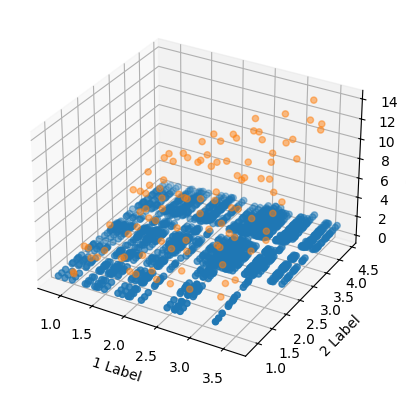

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

xs = useful_data['abs L2 err1']
ys = useful_data['abs L2 err2']
zs = useful_data['abs L2 err']
ax.scatter(xs, ys, zs, marker='o')

Xs = np.linspace(min(xs), max(xs), 100)
Ys = np.linspace(min(ys), max(ys), 100)
np.random.shuffle(Xs)
np.random.shuffle(Ys)
Zs = Xs * Ys

ax.scatter(Xs, Ys, Zs, alpha=0.5)

ax.set_xlabel('1 Label')
ax.set_ylabel('2 Label')
ax.set_zlabel('3 Label')

plt.show()

In [ ]:
# prompt: Using dataframe equal_to: PCA

from sklearn.decomposition import PCA
import pandas as pd

# Select the relevant columns for PCA
X = equal_to[['L2 err', 'L2 err1', 'L2 err2']]

# Create a PCA object
pca = PCA(n_components=3)

# Fit the PCA model to the data
principalComponents = pca.fit_transform(X)

# Create a new DataFrame with the principal components
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2', 'princ 3'])

# Print the explained variance ratio
print(pca.explained_variance_ratio_)
print((pca.components_[0,0]/pca.components_[:,0]))


[8.70772712e-01 1.29184219e-01 4.30691316e-05]
[ 1.          2.28121091 -1.29803902]


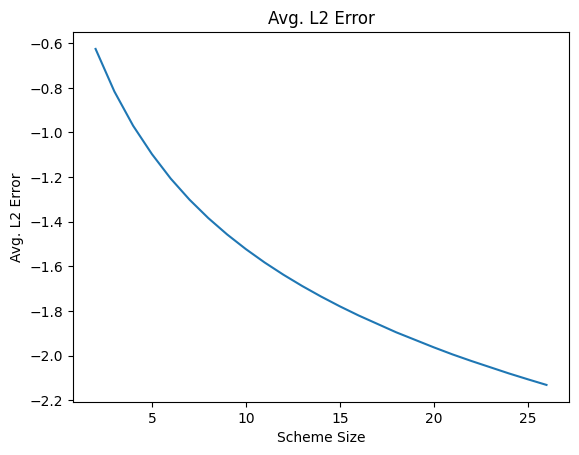

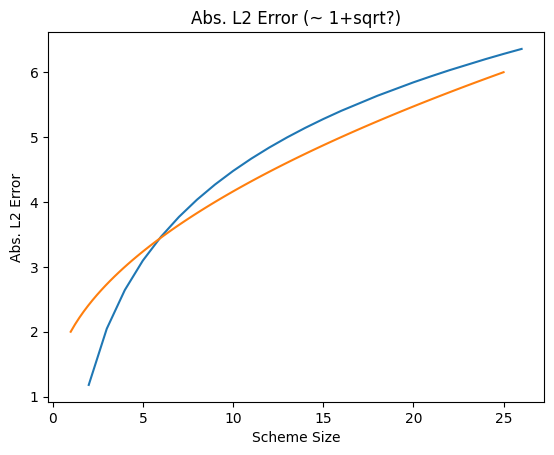

In [ ]:
#@title Average L2 errors decrease

perfect_schema_scores_L2 = {\
  2:  -0.6256,
  3:  -0.8161,
  4:  -0.9700,
  5:  -1.0969,
  6:  -1.2067,
  7:  -1.3011,
  8:  -1.3836,
  9:  -1.4568, # 5s
  10: -1.5227, # 7s
  11: -1.5827, # 21s
  12: -1.6375, # 38s
  13: -1.6881, # 1m 14s
  14: -1.7351, # 1m 46s
  15: -1.7790, # 3m 5s
  16: -1.8200, # 4m 12s
  # 17: -1, # PRIME
  18: -1.8954, # 3 x 6
  # 19: -1, # PRIME
  20: -1.9627, # 4 x 5
  21: -1.9945, # 3 x 7
  22: -2.0239, # 1 x 11
  # 23: -1, # PRIME
  24: -2.0797, # 4 x 6
  25: -2.1058, # 5 x 5
  26: -2.1312, # 2 x 13
  # 27: not enough RAM
  }

plt.plot(perfect_schema_scores_L2.keys(), perfect_schema_scores_L2.values())
plt.title("Avg. L2 Error")
plt.xlabel("Scheme Size")
plt.ylabel("Avg. L2 Error")
plt.show()

for key in perfect_schema_scores_L2:
  perfect_schema_scores_L2[key] += 6 * np.log10(key) # absolute error, not average error (multiply by n**6 entries in triple delta)

plt.plot(perfect_schema_scores_L2.keys(), perfect_schema_scores_L2.values())
plt.title("Abs. L2 Error (~ 1+sqrt?)")
plt.plot(np.linspace(1,25,100), 1+np.sqrt(np.linspace(1,25,100)))
plt.xlabel("Scheme Size")
plt.ylabel("Abs. L2 Error")
plt.show()